In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Lecture 17 Comparing Distributions

## Alameda County Jury Panels ##

### Is Racial Disparity in Jury Panels still a problem?
A 2010 report by the ACLU for Alameda County explores a possible issue in their jury selection process.

The population of eligible residents for jury service in Alameda County represents 5 different ethnicities.
The break down of the eligible population in 2010 was as follows:
 * Asian 15%
 * Black 18%
 * Latino 12%
 * White 54%
 * Other 1%

The distribution of the jury panels was as follows:
 * Asian 26%
 * Black 8%
 * Latino 8%
 * White 54%
 * Other 4%

Alameday county claimed their jury panels was selected without bias from the eligible population. ACLU claimed they selected with bias. We can use Data Science to analyze both claims and see which is more likely, statistically speaking. 

In [2]:
# Create a table that shows both the percent of eligible residents representing different ethnicities and the distribution of the jury panels.
 
jury = Table().with_columns(
    'Ethnicity', make_array('Asian', 'Black', 'Latino', 'White', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.12, 0.54, 0.01),
    'Panels', make_array(0.26, 0.08, 0.08, 0.54, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian,0.15,0.26
Black,0.18,0.08
Latino,0.12,0.08
White,0.54,0.54
Other,0.01,0.04


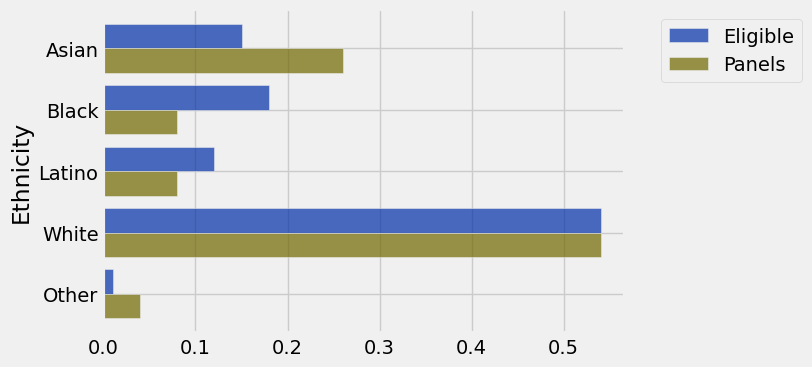

In [3]:
# Visually show the table data in a horizontal bar chart.
jury.barh('Ethnicity')

***QUESTION: Comparing the percentages and the visual display, is there any concern of bias?***

Alameda selects 1423 potential jurors to be on the panel from the population. We will simulate jury panel selection assuming there is no bias. That is, we will use the population distribution and select jurors at random then compare to the distribution Alameda got and said was fair.



In [5]:
# Under the model, this is the true distribution of people from which the jurors are randomly sampled
model = make_array(0.15, 0.18, 0.12, 0.54, 0.01)

In [6]:
# Let's simulate a random draw of 1423 jurors from this distribution
simulated = sample_proportions(1423, model)
simulated

array([ 0.13843992,  0.19044273,  0.12789881,  0.53127196,  0.01194659])

In [7]:
# COMPLETE: Create a table that adds the simulated values in the column 'Simulated'
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian,0.15,0.26,0.13844
Black,0.18,0.08,0.190443
Latino,0.12,0.08,0.127899
White,0.54,0.54,0.531272
Other,0.01,0.04,0.0119466


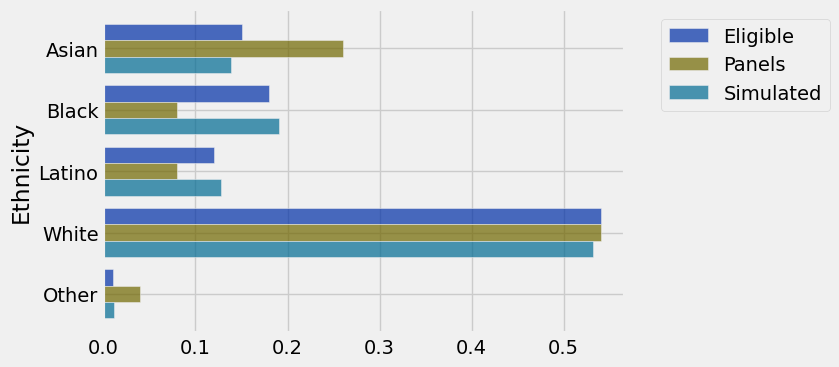

In [8]:
# COMPLETE: Create a horizontal bar graph that compares all three values. 

jury_with_simulated.barh('Ethnicity')

***QUESTION: Comparing the percentages and the visual display, is there any concern of bias?***


## Distance Between Distributions

In Mendel's model, the difference between observed white/purple and their expected values (26%/75%) was our statistic.

In this case, we need to understand how each of the 5 categories differ from their expected values according to the model, so we can't use a simple difference.


In [10]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


## Total Variation Distance (TVD)
 A new statistic (to us).

This statistic allows us to see difference when we are comparing more than two categories in a distribution.

Calculate the TVD using two distributions. For each category take the absolute value of the difference.
Add all the differences together, then divide by 2.

If the observed distribution is similar to the model, the TVD will be a small value.

In [11]:
# Creates a function that calculates the TVD of two distributions. 
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

In [13]:
# Calculates the TVD of our observed data (Panels) from Alameda's expected values
# assuming our model is true (Eligible)

obsvd_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
obsvd_tvd

0.14000000000000001

In [14]:
# The TVD of a model simluation from its expected values

tvd(sample_proportions(1423, model), jury.column('Eligible'))

0.023984539704848897

***QUESTION: What observations could you make when comparing the two TVDs above?***

In [15]:
# Create a function that will simulate juror panels of 1423, ten thousand times. 

def simulated_tvd():
    return tvd(sample_proportions(1423, model), model)

tvds = make_array()

num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

Observed TVD: 0.14


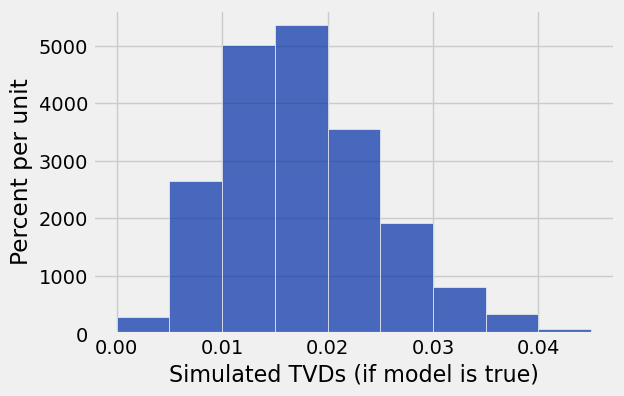

In [16]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, .05, .005)

#Create a histogram that will display the simulated TVDs using the given bins. 
Table().with_columns(title, tvds).hist(bins = bins)


#Leave this code, which will display the TVD of the actual juries.
print('Observed TVD: ' + str(obsvd_tvd))

***QUESTION: What observations could you make now that you have simulated 10000 TVDs?***